In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import xyzservices.providers as xyz
import contextily as cx

In [2]:
root_folder='C:\\Users\\57301\\Documents\\SONABIO'

In [3]:
extension='.shp'
directory=root_folder
extension = extension.lower()
archivos=[]
for dirpath, dirnames, files in os.walk(directory):
    for name in files:
        if extension and name.lower().endswith(extension):
            archivos.append(os.path.join(dirpath, name))
        elif not extension:
            archivos.append(os.path.join(dirpath, name))

In [4]:
mapa_path=archivos[0]

In [5]:
mapa_df=gpd.read_file('C:\\Users\\57301\\Documents\\SONABIO\\puinawai\\runap_id_pnn_02040002.shp')

In [7]:
metadata=pd.read_csv("C:\\Users\\57301\\Documents\\SONABIO\\sonabio_metadata.csv")
metadata_summary=pd.read_csv("C:\\Users\\57301\\Documents\\SONABIO\\sonabio_metadata_summary.csv")


In [21]:
microfonos=[folder for folder in list(os.walk(directory))[0][1] if 'MC' in folder ]

geo_info_microfonos=gpd.GeoDataFrame(microfonos, columns=['sensor_name'])
geo_info_microfonos['geometry']=mapa_df['geometry'].sample_points(geo_info_microfonos.shape[0]).explode().tolist()

C:\Users\57301\AppData\Local\Temp\ipykernel_16956\2411023831.py:4: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  geo_info_microfonos['geometry']=mapa_df['geometry'].sample_points(geo_info_microfonos.shape[0]).explode().tolist()


In [22]:
geo_info_microfonos =geo_info_microfonos.merge(metadata_summary,
                       on='sensor_name',
                       how='left'
                      )

In [23]:
geo_info_microfonos=geo_info_microfonos.astype({'n_recordings':'float64'})

C:\Users\57301\anaconda3\envs\pamenv\lib\site-packages\contextily\tile.py:645: UserWarning: The inferred zoom level of 26 is not valid for the current tile provider (valid zooms: 0 - 19).
  warnings.warn(msg)


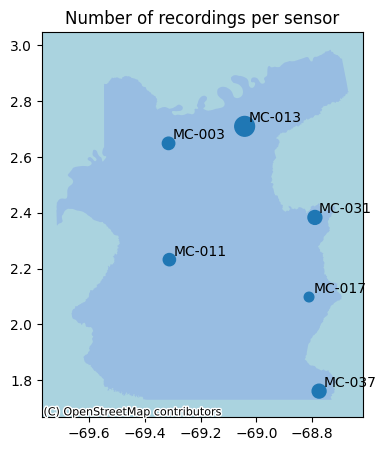

In [26]:
ax = mapa_df.plot(color="blue", alpha=0.1, figsize=(5, 5))
geo_info_microfonos.plot(ax=ax,
                         markersize=metadata_summary['n_recordings'],
                         
                        )

#ax.legend(metadata_summary['n_recordings'])

ax.set_title('Number of recordings per sensor')
cx.add_basemap(ax, source=xyz.OpenStreetMap.Mapnik)

for x, y, label in zip(geo_info_microfonos.geometry.x, geo_info_microfonos.geometry.y, geo_info_microfonos.sensor_name):
    ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points")



In [25]:
geo_info_microfonos

,sensor_name,geometry,date_ini,date_end,n_recordings,duration,time_diff,sample_length,sample_rate
0,MC-003,POINT (-69.31478 2.64882),2024-02-15 09:00:00,2024-02-17 00:30:00,80.0,1 days 15:30:00,0 days 00:30:00,60.0,48000
1,MC-011,POINT (-69.31184 2.23183),2024-03-09 22:00:00,2024-03-11 12:30:00,78.0,1 days 14:30:00,0 days 00:30:00,60.0,48000
2,MC-013,POINT (-69.04191 2.70982),2024-02-16 14:30:00,2024-02-20 19:00:00,202.0,4 days 04:30:00,0 days 00:30:00,60.0,48000
3,MC-017,POINT (-68.81105 2.09777),2024-02-16 11:00:00,2024-02-17 10:30:00,48.0,0 days 23:30:00,0 days 00:30:00,60.0,48000
4,MC-031,POINT (-68.78998 2.38321),2024-02-17 09:30:00,2024-02-19 11:00:00,100.0,2 days 01:30:00,0 days 00:30:00,60.0,48000
5,MC-037,POINT (-68.77497 1.76034),2024-02-19 10:30:00,2024-02-21 12:00:00,100.0,2 days 01:30:00,0 days 00:30:00,60.0,48000
